In [ ]:
################################################# visualize nnUNet probability maps overlayed on CT slices #################################################

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
import ipywidgets as widgets

# ============================================================
# Utility
# ============================================================

def load_nnUNet_probs(npz_path):
    data = np.load(npz_path)
    probs = data["probabilities"]  # (C, X, Y, Z)
    fg_probs = probs[1]    
    print(np.where(np.any(fg_probs > 0.2, axis=(1, 2)))[0])        # second channel = foreground
    return fg_probs

def load_ct_volume(ct_path):
    ct = nib.load(str(ct_path)).get_fdata()
    ct = np.transpose(ct, (2, 1, 0))  # match probabilities orientation
    return ct

def window_ct_hu(ct, level=50, width=350):
    lower = level - width / 2.0
    upper = level + width / 2.0
    ct = np.clip(ct, lower, upper)
    ct = (ct - lower) / (upper - lower + 1e-6)
    return ct

# ============================================================
# Interactive Visualization
# ============================================================

def visualize_prob_overlay_slider(ct_volume, prob_volume, axis="axial", cmap_name="jet"):
    axis_map = {"axial":0, "coronal":1, "sagittal":2}
    ax = axis_map[axis]
    n_slices = ct_volume.shape[ax]

    def plot_slice(idx):
        if axis == "axial":
            ct_slice = ct_volume[idx, :, :]
            prob_slice = prob_volume[idx, :, :]
        elif axis == "coronal":
            ct_slice = ct_volume[:, idx, :]
            prob_slice = prob_volume[:, idx, :]
        elif axis == "sagittal":
            ct_slice = ct_volume[:, :, idx]
            prob_slice = prob_volume[:, :, idx]

        ct_img = window_ct_hu(ct_slice)

        plt.figure(figsize=(6,6))
        plt.imshow(ct_img, cmap="gray", origin="lower")
        plt.imshow(prob_slice, cmap=cmap_name, alpha=0.2, origin="lower", vmin=0, vmax=1)
        plt.colorbar(label="Foreground probability")
        plt.title(f"{axis.capitalize()} slice {idx}/{n_slices-1}")
        plt.axis("off")
        plt.show()

    slice_slider = widgets.IntSlider(
        value=n_slices//2, min=0, max=n_slices-1, step=1,
        description=f'{axis.capitalize()} slice', continuous_update=False
    )

    widgets.interact(plot_slice, idx=slice_slider)

# ============================================================
# Example usage
# ============================================================

if __name__ == "__main__":
    
    uid = 339
    ct_path = f"/data/colon_cancer/CC_Detection/raw_data/Dataset107_CC/imagesTs/{uid}_0000.nii.gz"
    npz_path = f"/data/colon_cancer/CC_Detection/raw_data/Dataset107_CC/predictionsTs_cascade/{uid}.npz"

    ct = load_ct_volume(ct_path)
    fg_probs = load_nnUNet_probs(npz_path)

    visualize_prob_overlay_slider(ct, fg_probs, axis="axial")


In [ ]:
########################################################### visualize one sample from the dataset with its label ################################


from matplotlib.colors import ListedColormap
import pandas as pd 
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import ipywidgets as widgets
# ============================
# Utility Functions
# ============================

def load_volume(path):
    """Load a 3D volume from NIfTI (.nii.gz), NPZ, or NPY format."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    if path.suffix == ".npy":
        return np.load(path)
    elif path.suffix == ".npz":
        data = np.load(path)
        key = list(data.keys())[0]
        return data[key]
    elif path.suffix in [".nii", ".gz"]:
        return nib.load(str(path)).get_fdata()
    else:
        raise ValueError(f"Unsupported format: {path.suffix}")


def window_ct_hu(ct_hu, level=50, width=350):
    """Window the CT image for visualization."""
    lower, upper = level - width / 2.0, level + width / 2.0
    ct_clipped = np.clip(ct_hu, lower, upper)
    return (ct_clipped - lower) / (upper - lower + 1e-6)


def build_label_overlay(label_slice):
    """Return label colormap for segmentation overlay."""
    unique_labels = np.unique(label_slice)
    if np.array_equal(unique_labels, [0]) or np.array_equal(unique_labels, [0, 1]):
        cmap = ListedColormap([[0,0,0,0], [1,0,0,0.45]])  # red overlay
        return label_slice.astype(np.int32), cmap, (0, 1)
    colors = [[0, 0, 0, 0]]
    rng = np.random.default_rng(42)
    for _ in range(int(unique_labels.max())):
        colors.append([*rng.random(3), 0.45])
    cmap = ListedColormap(colors)
    return label_slice.astype(np.int32), cmap, (0, int(unique_labels.max()))


def get_slice(volume, axis, idx):
    """Extract a 2D slice along the chosen axis."""
    if axis == "axial":
        return volume[:, :, idx]
    elif axis == "coronal":
        return volume[:, idx, :]
    elif axis == "sagittal":
        return volume[idx, :, :]
    else:
        raise ValueError(f"Invalid axis: {axis}. Must be 'axial', 'coronal', or 'sagittal'.")


# ============================
# Main Visualization Function
# ============================

def visualize_case(ct_path, label_path, uid, target, axis="axial", save_dir=None,
                   window_level=50, window_width=350, save_all_slices=False):
    """Visualize a single case interactively, optionally saving overlays."""
    ct = load_volume(ct_path)
    label = load_volume(label_path)
    assert ct.shape == label.shape, f"Shape mismatch for {uid}: {ct.shape} vs {label.shape}"

    axis_to_dim = {"axial": 2, "coronal": 1, "sagittal": 0}
    n_slices = ct.shape[axis_to_dim[axis]]

    out_uid_dir = None
    if save_all_slices and save_dir:
        out_uid_dir = Path(save_dir) / str(uid)
        out_uid_dir.mkdir(parents=True, exist_ok=True)

    def plot_slice(idx):
        ct_slice = get_slice(ct, axis, idx)
        label_slice = get_slice(label, axis, idx)
        ct_img = window_ct_hu(ct_slice, window_level, window_width)
        lab_for_plot, lab_cmap, lab_vminmax = build_label_overlay(label_slice)

        plt.figure(figsize=(6, 6))
        plt.imshow(ct_img.T, cmap="gray", origin="lower")
        plt.imshow(lab_for_plot.T, cmap=lab_cmap, origin="lower",
                   vmin=lab_vminmax[0], vmax=lab_vminmax[1])
        plt.axis("off")
        plt.title(f"UID {uid} | Class: {target} | {axis.capitalize()} slice {idx}/{n_slices}")
        plt.tight_layout()

        if out_uid_dir:
            out_path = out_uid_dir / f"{axis}_slice{idx:03d}.png"
            plt.savefig(out_path, bbox_inches='tight')
            plt.close()
        else:
            plt.show()

    # Interactive slider
    slice_slider = widgets.IntSlider(
        value=n_slices // 2,
        min=0,
        max=n_slices - 1,
        step=1,
        description=f'UID {uid}',
        continuous_update=False
    )

    widgets.interact(plot_slice, idx=slice_slider)

    # Optionally save all slices automatically
    if save_all_slices and out_uid_dir:
        print(f"Saving all slices for UID {uid} → {out_uid_dir}")
        for i in range(n_slices):
            plot_slice(i)


def visualize_dataset(uids, img_root, label_root, axis="axial", save_dir=None, save_all_slices=False):
    """Visualize multiple UIDs."""
    img_root, label_root = Path(img_root), Path(label_root)
    df = pd.read_csv("/data/colon_cancer/CC_Detection/raw_data/Dataset100_CC/splits.csv")
    for uid in uids:
        # try naming patterns
        possible_names = [
            f"{uid}.nii.gz",f"{uid:03d}.nii.gz", f"{uid}_0000.nii.gz", f"{uid:03d}_0000.nii.gz",
            f"colon_{uid:03d}.nii.gz", f"{uid}.npy", f"{uid}.npz"
        ]
        
        
        img_path = next((img_root / n for n in possible_names if (img_root / n).exists()), None)
        label_path = next((label_root / n for n in possible_names if (label_root / n).exists()), None)
        print(img_path, label_path)
        if img_path is None or label_path is None:
            print(f"Skipping UID {uid}: missing image or label")
            continue

        row = df[df["UID"] == uid]
        target = row["target"].values[0]
        if target == 0:
            target = "div"
        else:
            target = "cc"

        visualize_case(img_path, label_path, uid, axis=axis, target=target,
                       save_dir=save_dir, save_all_slices=save_all_slices)


# ============================
# Example usage
# ============================

if __name__ == "__main__":
    uids = [108]
    img_root = "/data/colon_cancer/CC_Detection/raw_data/Dataset100_CC/imagesTr"
    label_root = "/data/colon_cancer/CC_Detection/raw_data/Dataset100_CC/labelsTr"
    
    save_dir = "/data/benchaaben/ColonCancerDetection/debug_notebooks/output_plot"

    visualize_dataset(uids, img_root, label_root,
                      axis="axial", save_dir=save_dir, save_all_slices=False)
    


    

In [ ]:
###################################### generate shapes statistics from pkl. files generated by the segmentation model #####################################
import pickle
import json

def analyze_pkl_folder(pkl_folder: str, output_json: str, output_csv: str = None):
    """
    Analyze a folder of .pkl files containing dictionaries of properties.
    Computes mean, median, min, max, 10th and 90th percentiles per dimension for each property.
    Optionally saves all individual values to a CSV for histogram plotting.
    """
    pkl_folder = Path(pkl_folder)
    if not pkl_folder.exists():
        raise FileNotFoundError(f"Folder not found: {pkl_folder}")

    # Initialize storage
    properties = {
        "shape_before_cropping": [],
        "shape_after_crop_before_resampling": [],
        "shape_after_resampling": [],
        "spacing": []
    }

    # Iterate over .pkl files
    for pkl_file in pkl_folder.glob("*.pkl"):
        with open(pkl_file, "rb") as f:
            data = pickle.load(f)

        for key in properties.keys():
            if key in data:
                properties[key].append(np.array(data[key]))

    # Helper to compute statistics
    def compute_stats(array_list):
        arr = np.stack(array_list, axis=0)
        stats = {
            "mean_shape": np.mean(arr, axis=0).tolist(),
            "median_shape": np.median(arr, axis=0).tolist(),
            "min_shape": np.min(arr, axis=0).tolist(),
            "max_shape": np.max(arr, axis=0).tolist(),
            "10pct_shape": np.percentile(arr, 10, axis=0).tolist(),
            "90pct_shape": np.percentile(arr, 90, axis=0).tolist()
        }
        return stats

    # Compute stats for each property
    results = {key: compute_stats(values) if values else {} for key, values in properties.items()}

    # Save JSON
    with open(output_json, "w") as f:
        json.dump(results, f, indent=4)
    print(f"Summary statistics saved to {output_json}")

    # Save raw values for histogram plotting if requested
    if output_csv:
        all_data = {}
        for key, values in properties.items():
            all_data[key] = [v.tolist() for v in values]  # convert arrays to lists
        # Convert to a DataFrame for easier plotting
        df = pd.DataFrame({k: pd.Series(v) for k, v in all_data.items()})
        df.to_csv(output_csv, index=False)
        print(f"All individual values saved to {output_csv}")



analyze_pkl_folder(
     pkl_folder="/data/benchaaben/ColonCancerDetection/stats_pkl",
     output_json="dataset_stats.json",
     output_csv="dataset_stats_raw.csv"
 )


In [ ]:
import ast

def parse_numeric_tuple_or_list(s):
    """
    Convert a string like '(1.0, 1.0, 1.5)' or '[1.0, 1.0, 1.5]' to a numpy array of floats.
    """
    if isinstance(s, str):
        try:
            t = ast.literal_eval(s)
            return np.array(t, dtype=float)
        except:
            raise ValueError(f"Cannot parse {s} as a numeric tuple/list")
    return np.array(s, dtype=float)

def plot_metric_histogram(csv_path, metric_column="original_shape", percentiles=(10, 90)):
    """
    Plots histograms for a given numeric metric column from a CSV.
    Supports columns with tuple/list-like entries (e.g., spacing or shapes) or single numeric values.
    """
    df = pd.read_csv(csv_path)

    # Check if the first value looks like a tuple or list
    sample_val = df[metric_column].iloc[0]
    if isinstance(sample_val, str) and (sample_val.startswith("(") or sample_val.startswith("[")):
        df[metric_column] = df[metric_column].apply(parse_numeric_tuple_or_list)
        values = np.stack(df[metric_column].values)  # shape (N, D)
        axis_labels = [f"dim {i}" for i in range(values.shape[1])]
    else:
        # Single numeric column
        values = df[metric_column].to_numpy(dtype=float).reshape(-1, 1)
        axis_labels = [metric_column]

    # Plot histograms
    fig, axs = plt.subplots(1, values.shape[1], figsize=(5 * values.shape[1], 4))
    if values.shape[1] == 1:
        axs = [axs]

    for i, ax in enumerate(axs):
        vals = values[:, i]
        mean_val = np.mean(vals)
        median_val = np.median(vals)
        min_val = np.min(vals)
        max_val = np.max(vals)
        p_low, p_high = np.percentile(vals, percentiles)

        ax.hist(vals, bins=20, color="lightcoral", edgecolor="black", alpha=0.7)
        ax.axvline(mean_val, color="orange", linestyle="--", label=f"Mean: {mean_val:.2f}")
        ax.axvline(median_val, color="red", linestyle="-.", label=f"Median: {median_val:.2f}")
        ax.axvline(min_val, color="green", linestyle=":", label=f"Min: {min_val:.2f}")
        ax.axvline(max_val, color="purple", linestyle=":", label=f"Max: {max_val:.2f}")
        ax.axvline(p_low, color="gray", linestyle="--", label=f"{percentiles[0]}th: {p_low:.2f}")
        ax.axvline(p_high, color="gray", linestyle="--", label=f"{percentiles[1]}th: {p_high:.2f}")

        ax.set_title(f" - {axis_labels[i]}")
        ax.set_xlabel("Value")
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    #plt.suptitle(f"Distribution of the CT spacial dimensions after 1 mm isotropic resampling", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


plot_metric_histogram("/data/colon_cancer/CC_Detection/pp_data/Dataset107_CC/resampling_metadata_Tr.csv", metric_column="resampled_size")
#plot_metric_histogram("/data/colon_cancer/CC_Detection/pp_data/Dataset107_CC/cropping_metadata_Tr.csv", metric_column="original_shape")
#plot_metric_histogram("/data/colon_cancer/CC_Detection/pp_data/Dataset107_CC/cropping_metadata_Tr.csv", metric_column="cropped_shape")

Matched files: 20

=== Global Dice ===
N      : 20
Mean   : 0.522
Median : 0.605
Q1/Q3  : 0.386 / 0.697
Min/Max: 0.041 / 0.883

=== Category = bad ===
N      : 5
Mean   : 0.161
Median : 0.166
Q1/Q3  : 0.162 / 0.168
Min/Max: 0.041 / 0.267

=== Category = medium ===
N      : 11
Mean   : 0.584
Median : 0.606
Q1/Q3  : 0.536 / 0.619
Min/Max: 0.425 / 0.699

=== Category = good ===
N      : 4
Mean   : 0.805
Median : 0.791
Q1/Q3  : 0.780 / 0.816
Min/Max: 0.756 / 0.883

=== Class 0 ===
N      : 9
Mean   : 0.423
Median : 0.476
Q1/Q3  : 0.168 / 0.606
Min/Max: 0.041 / 0.699

=== Class 1 ===
N      : 11
Mean   : 0.604
Median : 0.607
Q1/Q3  : 0.540 / 0.772
Min/Max: 0.162 / 0.883


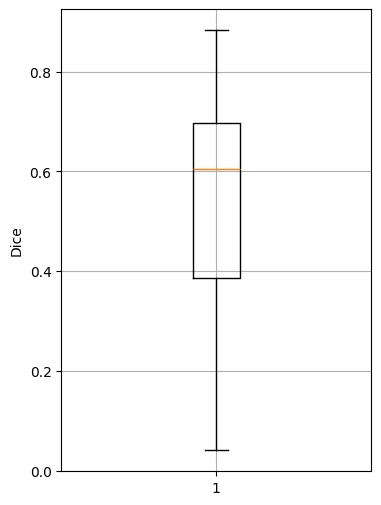

/tmp/ipykernel_1201776/3551055273.py:101: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cat_data, labels=["bad", "medium", "good"])


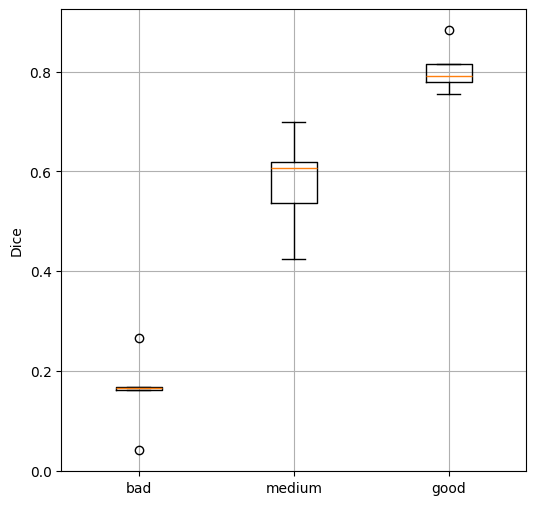

/tmp/ipykernel_1201776/3551055273.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(class_data, labels=[f"Class {c}" for c in classes])


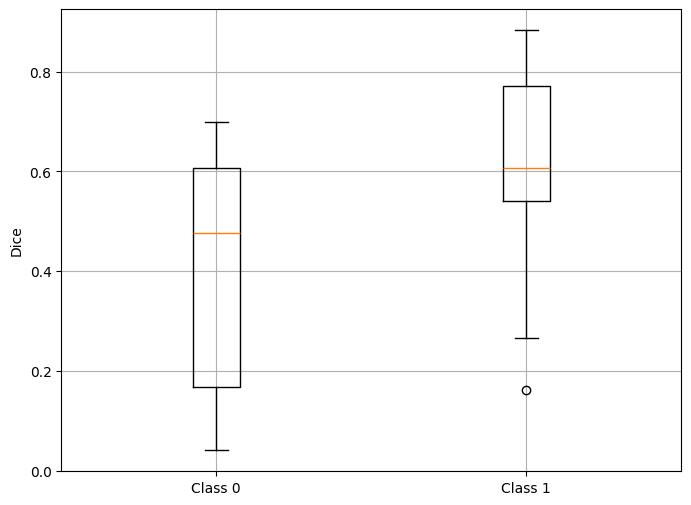

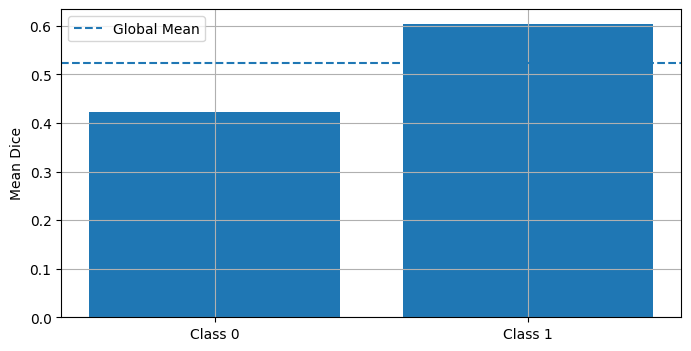

In [4]:
############################################### Post-process Dice results and generate statistics and plots ###############################################
from pathlib import Path
import json 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
# =============================
# Paths
# =============================
json_path = Path("/data/benchaaben/DINOv2-3D-Med/dice_results_orig.json")
csv_path  = Path("/data/colon_cancer/CC_Detection/raw_data/Dataset100_CC/splits.csv")  # <-- change

# =============================
# Load data
# =============================
with open(json_path, "r") as f:
    results = json.load(f)

per_file = results["per_file"]

df = pd.read_csv(csv_path)
df["UID"] = df["UID"].astype(str)

# =============================
# Build Dice table
# =============================
rows = []

for fname, v in per_file.items():
    uid = fname.replace(".nii.gz", "")
    dice = v["dice"]
    category = v["category"]

    match = df[df["UID"] == uid]
    if len(match) == 0:
        continue

    target = int(match.iloc[0]["target"])

    rows.append({
        "uid": uid,
        "dice": dice,
        "category": category,
        "class": target
    })

dice_df = pd.DataFrame(rows)

print(f"Matched files: {len(dice_df)}")

# =============================
# Statistics helpers
# =============================
def print_stats(name, values):
    values = np.array(values)
    print(f"\n=== {name} ===")
    print(f"N      : {len(values)}")
    print(f"Mean   : {values.mean():.3f}")
    print(f"Median : {np.median(values):.3f}")
    print(f"Q1/Q3  : {np.percentile(values,25):.3f} / {np.percentile(values,75):.3f}")
    print(f"Min/Max: {values.min():.3f} / {values.max():.3f}")

# =============================
# 1. Global statistics
# =============================
print_stats("Global Dice", dice_df["dice"])

# =============================
# 2. Per category statistics
# =============================
for cat in ["bad", "medium", "good"]:
    vals = dice_df[dice_df["category"] == cat]["dice"]
    print_stats(f"Category = {cat}", vals)

# =============================
# 3. Per class statistics
# =============================
for cls in sorted(dice_df["class"].unique()):
    vals = dice_df[dice_df["class"] == cls]["dice"]
    print_stats(f"Class {cls}", vals)

# =============================
# Plotting
# =============================

# ---------- Plot 1: Global ----------
plt.figure(figsize=(4,6))
plt.boxplot(dice_df["dice"], vert=True)
plt.ylabel("Dice")
#plt.title("Global Dice Distribution")
plt.grid(True)
plt.show()

# ---------- Plot 2: By category ----------
cat_data = [
    dice_df[dice_df["category"] == c]["dice"]
    for c in ["bad", "medium", "good"]
]

plt.figure(figsize=(6,6))
plt.boxplot(cat_data, labels=["bad", "medium", "good"])
plt.ylabel("Dice")
#plt.title("Dice Distribution by Category")
plt.grid(True)
plt.show()

# ---------- Plot 3: Per class ----------
classes = sorted(dice_df["class"].unique())
class_data = [
    dice_df[dice_df["class"] == c]["dice"]
    for c in classes
]

plt.figure(figsize=(8,6))
plt.boxplot(class_data, labels=[f"Class {c}" for c in classes])
plt.ylabel("Dice")
#plt.title("Dice Distribution per Class")
plt.grid(True)
plt.show()

# ---------- Plot 4: Aggregated vs Per-Class Mean ----------
means = [dice_df[dice_df["class"] == c]["dice"].mean() for c in classes]

plt.figure(figsize=(8,4))
plt.bar([f"Class {c}" for c in classes], means)
plt.axhline(dice_df["dice"].mean(), linestyle="--", label="Global Mean")
plt.ylabel("Mean Dice")
#plt.title("Mean Dice per Class vs Global")
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
###############################################
# Metrics statistics & distribution plots
# (BEFORE only: Dice, Precision, Recall)
###############################################

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path


# =============================
# Global plotting style
# =============================
mpl.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "figure.titlesize": 20,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# =============================
# Paths (EDIT THESE)
# =============================
json_path = Path(
    "/data/benchaaben/ColonCancerDetection/debug_notebooks/metrics_results_postprocessing_109ts.json"
)
class_csv = Path(
    "/data/colon_cancer/CC_Detection/raw_data/Dataset109_CC/labels.csv"
)

# =============================
# Load JSON
# =============================
with open(json_path, "r") as f:
    results = json.load(f)

per_case = results["per_case"]

# =============================
# Build DataFrame (BEFORE only)
# =============================
rows = []
for uid, v in per_case.items():
    rows.append({
        "uid": str(uid),
        "dice": v["before"]["dice"],
        "precision": v["before"]["precision"],
        "recall": v["before"]["recall"],
    })

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} cases")

# =============================
# Load UID → class mapping
# =============================
class_df = pd.read_csv(class_csv)
class_df["UID"] = class_df["UID"].astype(str)

df = df.merge(class_df, left_on="uid", right_on="UID", how="left")
df = df.drop(columns=["UID"])

print("\nClass distribution:")
print(df["target"].value_counts())

# =============================
# Statistics helpers
# =============================
def compute_stats(values):
    values = np.asarray(values)
    return {
        "N": len(values),
        "mean": np.mean(values),
        "median": np.median(values),
        "q1": np.percentile(values, 25),
        "q3": np.percentile(values, 75),
        "min": np.min(values),
        "max": np.max(values),
    }

def print_stats(name, values):
    s = compute_stats(values)
    print(f"\n=== {name} ===")
    print(f"N      : {s['N']}")
    print(f"Mean   : {s['mean']:.3f}")
    print(f"Median : {s['median']:.3f}")
    print(f"Q1/Q3  : {s['q1']:.3f} / {s['q3']:.3f}")
    print(f"Min/Max: {s['min']:.3f} / {s['max']:.3f}")

# =============================
# Print statistics
# =============================
for metric in ["dice", "precision", "recall"]:
    print_stats(f"Global {metric.capitalize()}", df[metric])

    for cls in sorted(df["target"].dropna().unique()):
        vals = df[df["target"] == cls][metric]
        print_stats(f"Class {cls} — {metric.capitalize()}", vals)

# =============================
# Plotting helper
# =============================
def plot_metric(metric, ylabel):
    class_map = {
        0: "Diverticulitis",
        1: "Colon Cancer",
    }

    classes = [c for c in class_map if c in df["target"].unique()]
    labels = [class_map[c] for c in classes]

    box_colors = ["#2ECC71", "#E74C3C"]   # boxplots
    bar_colors = ["#2ECC71", "#E74C3C"]   # bar plots

    boxprops = dict(linewidth=1.8)
    whiskerprops = dict(linewidth=1.6)
    capprops = dict(linewidth=1.6)
    medianprops = dict(color="black", linewidth=2)

    # ---------- Plot 1: Aggregated ----------
    fig, ax = plt.subplots(figsize=(4, 6))

    bp = ax.boxplot(
        df[metric],
        patch_artist=True,
        boxprops=boxprops,
        whiskerprops=whiskerprops,
        capprops=capprops,
        medianprops=medianprops,
    )

    bp["boxes"][0].set_facecolor("#4C72B0")

    ax.set_xticks([1])
    ax.set_xticklabels(["Global"])
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} (All cases)")
    ax.grid(False)

    plt.tight_layout()
    plt.show()

# ---------- Plot 2: By class + global mean annotation ----------
    class_data = [df[df["target"] == c][metric] for c in classes]
    global_mean = df[metric].mean()

    fig, ax = plt.subplots(figsize=(6, 6))

    bp = ax.boxplot(
        class_data,
        labels=labels,
        patch_artist=True,
        boxprops=boxprops,
        whiskerprops=whiskerprops,
        capprops=capprops,
        medianprops=medianprops,
    )

    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)

    # Color x-axis tick labels to match box colors
    for tick_label, color in zip(ax.get_xticklabels(), box_colors):
        tick_label.set_color(color)
        tick_label.set_fontweight("bold")


    # Axis labels only (no title)
    ax.set_ylabel(ylabel)
    ax.grid(False)

    # --- Global mean box (top-left) ---
    ax.text(
        0.5,
        0.98,
        f"Global mean:{global_mean:.2f}",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=13,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black",
            linewidth=1.2,
        ),
    )

    plt.tight_layout()
    plt.show()


    # ---------- Plot 3: Mean per class ----------
    means = [df[df["target"] == c][metric].mean() for c in classes]

    fig, ax = plt.subplots(figsize=(6, 4))

    bars = ax.bar(labels, means, color=bar_colors, width=0.6)

    ax.set_ylabel(f"Mean {ylabel}")
    ax.set_title(f"Mean {ylabel} per class")
    ax.grid(False)

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=13,
        )

    plt.tight_layout()
    plt.show()

# =============================
# Generate plots
# =============================
plot_metric("dice", "Dice Coefficient")
plot_metric("precision", "Precision")
plot_metric("recall", "Recall")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from pathlib import Path

# ============================================================
# IO
# ============================================================

def load_volume(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    if path.suffix == ".npy":
        return np.load(path)
    elif path.suffix in [".nii", ".gz"]:
        return nib.load(str(path)).get_fdata()
    else:
        raise ValueError(f"Unsupported format: {path}")

def load_case(uid, img_dir, gt_dir, pred_dir):
    img_path = Path(img_dir)
    gt_path = Path(gt_dir)
    pred_path = Path(pred_dir)

    if img_path.is_file():
        img = load_volume(img_path)
        gt = load_volume(gt_path)
        pred = load_volume(pred_path)
    else:
        img = load_volume(img_path / f"{uid}_0000.nii.gz")
        gt = load_volume(gt_path / f"{uid}.nii.gz")
        pred = load_volume(pred_path / f"{uid}.nii.gz")

    assert img.shape == gt.shape == pred.shape
    return img, gt, pred

def window_ct_hu(ct, level=50, width=350):
    lo, hi = level - width / 2, level + width / 2
    ct = np.clip(ct, lo, hi)
    return (ct - lo) / (hi - lo + 1e-6)

# ============================================================
# Slice selection & Square BBox
# ============================================================

def select_annotated_slices(mask, axis, num_slices):
    proj = mask.sum(axis=tuple(i for i in range(3) if i != axis))
    valid = np.where(proj > 0)[0]
    if len(valid) == 0:
        raise ValueError("No annotated slices found")
    if num_slices >= len(valid):
        return valid.tolist()
    return np.linspace(valid.min(), valid.max(), num_slices, dtype=int).tolist()

def compute_square_bbox(mask, axis, margin=100):
    coords = np.where(mask > 0)
    axes_2d = [0, 1, 2]
    axes_2d.remove(axis)

    y_min, y_max = coords[axes_2d[0]].min(), coords[axes_2d[0]].max()
    x_min, x_max = coords[axes_2d[1]].min(), coords[axes_2d[1]].max()

    h = y_max - y_min + 1
    w = x_max - x_min + 1
    size = max(h, w) + margin

    cy = (y_min + y_max) // 2
    cx = (x_min + x_max) // 2

    y0 = max(0, cy - size // 2)
    x0 = max(0, cx - size // 2)
    print(x0, y0, size, mask.shape)
    return y0, y0 + size, x0, x0 + size

def crop_and_rotate(slice2d, bbox):
    y0, y1, x0, x1 = bbox
    cropped = slice2d[y0:y1, x0:x1]
    return np.rot90(cropped, k=1)

# ============================================================
# Overlay helpers (Paper colors)
# ============================================================

def overlay_single(ax, ct, mask, color, alpha=0.5):
    ax.imshow(ct, cmap="gray")
    overlay = np.zeros((*mask.shape, 4))
    overlay[..., :3] = color
    overlay[..., 3] = mask * alpha
    ax.imshow(overlay)
    ax.axis("off")

def overlay_comparison(ax, ct, gt, pred, alpha=0.6):
    ax.imshow(ct, cmap="gray")

    tp = gt & pred
    gt_only = gt & ~pred
    pred_only = pred & ~gt

    overlay = np.zeros((*gt.shape, 4))
    overlay[gt_only, :3] = [1, 0, 0]        # Red
    overlay[pred_only, :3] = [0, 0, 1]      # Blue
    overlay[tp, :3] = [0.6, 0, 0.6]          # Purple

    overlay[..., 3] = (gt_only | pred_only | tp) * alpha
    ax.imshow(overlay)
    ax.axis("off")

# ============================================================
# Plot & Save (One figure per UID)
# ============================================================

def plot_and_save_sample(
    ct, gt, pred, uid, slice_ids,
    axis=2, save_dir="figures"
):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    gt_bin = gt > 0
    pred_bin = pred > 0
    union = gt_bin | pred_bin
    bbox = compute_square_bbox(union, axis)

    fig, axes = plt.subplots(
        len(slice_ids), 3,
        figsize=(9, 3 * len(slice_ids))
    )

    if len(slice_ids) == 1:
        axes = axes[None, :]

    # -------------------------
    # Column titles (top row)
    # -------------------------
    col_titles = ["GT", "Prediction", "Error map"]
    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title, fontsize=12, pad=10)

    for i, z in enumerate(slice_ids):
        if axis == 2:
            ct_sl = ct[:, :, z]
            gt_sl = gt_bin[:, :, z]
            pr_sl = pred_bin[:, :, z]
        elif axis == 1:
            ct_sl = ct[:, z, :]
            gt_sl = gt_bin[:, z, :]
            pr_sl = pred_bin[:, z, :]
        else:
            ct_sl = ct[z, :, :]
            gt_sl = gt_bin[z, :, :]
            pr_sl = pred_bin[z, :, :]

        ct_sl = window_ct_hu(ct_sl)

        ct_sl = crop_and_rotate(ct_sl, bbox)
        gt_sl = crop_and_rotate(gt_sl, bbox)
        pr_sl = crop_and_rotate(pr_sl, bbox)

        overlay_single(axes[i, 0], ct_sl, gt_sl, [1, 0, 0])
        overlay_single(axes[i, 1], ct_sl, pr_sl, [0, 0, 1])
        overlay_comparison(axes[i, 2], ct_sl, gt_sl, pr_sl)

        # -------------------------
        # Row label = slice number
        # -------------------------
        axes[i, 0].text(
            -0.25, 0.5,
            f"Slice {z}",
            transform=axes[i, 0].transAxes,
            fontsize=11,
            va="center",
            ha="right"
        )

    # -------------------------
    # Global title = UID
    # -------------------------
    
    fig.text(
        0.5, 0.01,
        f"Case ID: {uid}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

    plt.subplots_adjust(wspace=0.01, hspace=0.05, top=0.93)

    out_path = save_dir / f"qualitative_uid_{uid}.pdf"
    plt.savefig(out_path, bbox_inches="tight")
    plt.show()

    print(f"Saved: {out_path}")

# ============================================================
# Dataset-level interface
# ============================================================

def visualize_uids(
    uids, img_dir, gt_dir, pred_dir,
    axis=2, slice_map=None, num_slices=3,
    save_dir="figures"
):
    for uid in uids:
        print(f"Processing UID {uid}...")
        ct, gt, pred = load_case(uid, img_dir, gt_dir, pred_dir)

        union = (gt > 0) | (pred > 0)
        if slice_map and uid in slice_map:
            slices = slice_map[uid]
        else:
            slices = select_annotated_slices(union, axis, num_slices)

        plot_and_save_sample(
            ct, gt, pred,
            uid, slices,
            axis=axis,
            save_dir=save_dir
        )

# ============================================================
# Run
# ============================================================

"""
uids = [ 339, 86, 571,330,206]
#uids = [206]
slice_map = {
    330:[22, 23, 25],
    206:[31, 40, 50],
    399: [20, 25, 26],
    339: [155, 169, 180],
    86: [18, 21, 28],
    571: [46, 51, 56],
}
801, 12, 695, 404, 172, 245
"""
uids = [245]
slice_map = {
    245:[31,36 , 39],}
visualize_uids(
    uids,
    img_dir="/data/colon_cancer/CC_Detection/raw_data/Dataset109_CC/imagesTs",
    gt_dir="/data/colon_cancer/CC_Detection/raw_data/Dataset109_CC/labelsTs",
    pred_dir="/data/colon_cancer/CC_Detection/raw_data/Dataset109_CC/predictionsTs_pp",
    axis=2,
    slice_map=slice_map,
    save_dir="figures"
)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import random
import nibabel as nib

# ===============================
# batchgeneratorsv2 imports
# ===============================
from batchgeneratorsv2.transforms.intensity.contrast import ContrastTransform
from batchgeneratorsv2.transforms.intensity.gamma import GammaTransform
from batchgeneratorsv2.transforms.intensity.gaussian_noise import GaussianNoiseTransform
from batchgeneratorsv2.transforms.noise.gaussian_blur import GaussianBlurTransform
from batchgeneratorsv2.transforms.spatial.low_resolution import SimulateLowResolutionTransform
from batchgeneratorsv2.transforms.spatial.mirroring import MirrorTransform
from batchgeneratorsv2.transforms.spatial.spatial import SpatialTransform
from batchgeneratorsv2.transforms.intensity.brightness import MultiplicativeBrightnessTransform
from batchgeneratorsv2.transforms.utils.remove_label import RemoveLabelTansform


# ==========================================================
# Reproducibility (CRITICAL for papers)
# ==========================================================
def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


# ==========================================================
# CT windowing (visualization only)
# ==========================================================
def window_ct(img, center=50, width=350):
    """
    img: 2D numpy array (HU)
    """
    lower = center - width / 2
    upper = center + width / 2
    img = np.clip(img, lower, upper)
    img = (img - lower) / (upper - lower)
    return img


# ==========================================================
# Helper: visualize & save one slice
# ==========================================================
def save_slice(img, seg, out_path, slice_idx, title=None):
    """
    img: (C, Z, Y, X) torch.Tensor
    seg: (1, Z, Y, X) torch.Tensor
    """
    img2d = img[0, :, :, slice_idx].cpu().numpy()
    seg2d = seg[0, :, :, slice_idx].cpu().numpy() > 0

    # Window CT
    img2d = window_ct(img2d)

    h, w = img2d.shape

    # Create figure at EXACT pixel resolution
    dpi = 100
    fig = plt.figure(figsize=(w / dpi, h / dpi), dpi=dpi)
    ax = plt.Axes(fig, [0., 0., 1., 1.])
    ax.set_axis_off()
    fig.add_axes(ax)


    ax.imshow(
        img2d,
        cmap="gray",
        origin="lower",
    )


    if title is not None:
        ax.set_title(title, fontsize=10, pad=4)

    fig.savefig(
        out_path,
        dpi=dpi,
        bbox_inches="tight",
        pad_inches=0,
    )
    plt.close(fig)



# ==========================================================
# Apply nnU-Net transforms ONE BY ONE (independent)
# ==========================================================
def visualize_transforms(
    image,
    segmentation,
    output_dir,
    patch_size=(256, 160, 192),
    slice_idx=None,
):
    """
    image: (C, Z, Y, X)
    seg:   (1, Z, Y, X)
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    #set_seed(0)

    if slice_idx is None:
        slice_idx = image.shape[1] // 2

    original_data = {
        "image": image.clone(),
        "segmentation": segmentation.clone(),
    }

    transforms = [
        ("00_original", None),
        ("01_spatial_scaling",
         SpatialTransform(
             patch_size=patch_size,
             patch_center_dist_from_border=0,
             random_crop=False,
             p_elastic_deform=0,
             p_rotation=0.0,
             rotation=(-0.5235988, 0.5235988),
             p_scaling=1.0,
             scaling=(0.7, 1.4),
             p_synchronize_scaling_across_axes=1,
             bg_style_seg_sampling=False,
         )),
        # ----------------------------
        # Mirror
        # ----------------------------
        

    ]

    # ----------------------------
    # Apply + save (independent)
    # ----------------------------
    for name, transform in transforms:
        if transform is None:
            data = {
                "image": original_data["image"].clone(),
                "segmentation": original_data["segmentation"].clone(),
            }
        else:
            data = transform(
                image=original_data["image"].clone(),
                segmentation=original_data["segmentation"].clone(),
            )

        save_slice(
            data["image"],
            data["segmentation"],
            output_dir / f"{name}.png",
            slice_idx,
            #title=name.replace("_", " "),
        )

    print(f"✅ Saved nnU-Net augmentation visualization to: {output_dir}")


# ==========================================================
# Data loading
# ==========================================================
def load_volume(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    if path.suffix == ".npy":
        return np.load(path)

    elif path.suffix == ".npz":
        data = np.load(path)
        return data[list(data.keys())[0]]

    elif path.suffix in [".nii", ".gz"]:
        return nib.load(str(path)).get_fdata()

    else:
        raise ValueError(f"Unsupported format: {path.suffix}")


# ==========================================================
# Example usage
# ==========================================================
image = load_volume(
    "/data/colon_cancer/CC_Detection/raw_data/Dataset100_CC/imagesTr/55_0000.nii.gz"
)
segmentation = load_volume(
    "/data/colon_cancer/CC_Detection/raw_data/Dataset100_CC/labelsTr/55.nii.gz"
)

# Add channel dimensions
image = torch.from_numpy(image).float()[None]          # (1, Z, Y, X)
segmentation = torch.from_numpy(segmentation).long()[None]

print("Image shape:", image.shape)
print("Seg shape:", segmentation.shape)

visualize_transforms(
    image,
    segmentation,
    output_dir="transform_visualizations",
    patch_size=(512, 512, 128),
    slice_idx=60,
)


In [ ]:
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import roc_curve, auc
from scipy.interpolate import pchip_interpolate

# ==========================================
# 1. High-End Publication Styling (LaTeX look)
# ==========================================
mpl.rcParams.update({
    "font.family": "serif",        # Matches LaTeX Serif style
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.spines.top": False,      # Clean "Descartes" style
    "axes.spines.right": False,
    "axes.linewidth": 1.2,
    "legend.fontsize": 14,
    "mathtext.fontset": "stix",    # Academic math font
})


# -------- CONFIG --------
csv_path = (
    "/data/colon_cancer/CC_Detection/Resnet_results/inf_outputs/"
    "ResNet_Dataset110_CC_2026_02_11_172950/Dataset110_CC/results.csv"
)
gt_col = "GT"
prob_col = "NN_pred"
positive_class_index = 1

# Load data
df = pd.read_csv(csv_path)
y_true = df[gt_col].values
y_scores = df[prob_col].apply(lambda x: ast.literal_eval(x)[positive_class_index]).values

# Compute raw ROC
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# ==========================================
# 2. Monotonic Smoothing (PCHIP) - FIXED
# ==========================================
# 1. Filter out duplicate FPR values to ensure x is strictly increasing
# np.unique returns unique values and their first occurrence indices
_, unique_indices = np.unique(fpr, return_index=True)
fpr_unique = fpr[unique_indices]
tpr_unique = tpr[unique_indices]

# 2. Smooth the curve using unique values
fpr_smooth = np.linspace(0, 1, 200)
tpr_smooth = pchip_interpolate(fpr_unique, tpr_unique, fpr_smooth)
tpr_smooth = np.clip(tpr_smooth, 0, 1) # Ensure within valid range

# ==========================================
# 3. Enhanced Plotting
# ==========================================
fig, ax = plt.subplots(figsize=(7, 7), dpi=120)

# Add a soft shaded area under the curve
ax.fill_between(fpr_smooth, tpr_smooth, alpha=0.1, color="#1C4E80")

# Main ROC Line (Deep Medical Blue)
ax.plot(
    fpr_smooth,
    tpr_smooth,
    color="#1C4E80",
    lw=2.5,
    label=rf"$\mathbf{{AUC = {roc_auc:.3f}}}$", # LaTeX bold formatting
    zorder=3
)

# Reference "Chance" Line
ax.plot(
    [0, 1], [0, 1],
    linestyle="--",
    color="#A2A2A2",
    lw=1.2,
    alpha=0.8,
    label="Random Chance",
    zorder=2
)

# Refine Axes
ax.set_xlim(-0.01, 1.0)
ax.set_ylim(0.0, 1.02)
ax.set_xlabel("False Positive Rate (1 − Specificity)", labelpad=12)
ax.set_ylabel("True Positive Rate (Sensitivity)", labelpad=12)

# Optional: Add an "Optimal Threshold" marker if you have one
# ax.scatter(fpr_opt, tpr_opt, color='red', s=50, label='Optimal Threshold', zorder=5)

ax.grid(color='gray', linestyle=':', linewidth=0.5, alpha=0.3)
ax.legend(loc="lower right", frameon=False)

plt.tight_layout()
plt.savefig("smooth_roc_curve.pdf", bbox_inches='tight') # Saves as vector for your paper
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ==========================================
# 1. Consistent Publication Styling
# ==========================================
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "mathtext.fontset": "stix",
})

# Confusion matrix values from your results
cm = np.array([
    [26, 6],
    [1, 44]
])

class_names = ["Diverticulitis", "Colon Cancer"]
label_colors = ["#2E7D32", "#C62828"] 

# ==========================================
# 2. Enhanced Visualization with Aligned Labels
# ==========================================
fig, ax = plt.subplots(figsize=(7, 6), dpi=120)

# Main plot
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues, alpha=0.8)

# Remove spines for clean academic look
for spine in ax.spines.values():
    spine.set_visible(False)

# Title and Axis Headings
ax.set_title("Confusion Matrix: Differential Diagnosis", pad=25, fontweight='bold')
ax.set_ylabel("True Pathology", labelpad=25, fontweight='bold')
ax.set_xlabel("Predicted Pathology", labelpad=25, fontweight='bold')

# Set tick positions
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))

# SET HORIZONTAL X-LABELS
ax.set_xticklabels(class_names, ha='center')

# SET HORIZONTAL Y-LABELS (rotation=0 ensures they align with the text flow)
ax.set_yticklabels(class_names, rotation=0, va='center')

# Apply specific colors to tick labels
for i, tick in enumerate(ax.get_xticklabels()):
    tick.set_color(label_colors[i])
    tick.set_fontweight('bold')
    
for i, tick in enumerate(ax.get_yticklabels()):
    tick.set_color(label_colors[i])
    tick.set_fontweight('bold')

# Add cell values with adaptive contrast
thresh = cm.max() / 1.5 # Adjusted threshold for text color flip
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=20, fontweight='bold')

# Clean colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.1) # Increased pad to avoid label overlap
cbar.outline.set_visible(False)

plt.tight_layout()
plt.savefig("confusion_matrix_aligned.pdf", bbox_inches='tight')
plt.show()

In [ ]:
import json
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
from sklearn.metrics import roc_curve, auc
from scipy.interpolate import pchip_interpolate

# ==========================================
# 1. GLOBAL PUBLICATION STYLE (LaTeX/Serif)
# ==========================================
# Consistent colors: Green for Diverticulitis (#2E7D32), Red for Cancer (#C62828)
COLOR_DIVERT = "#2E7D32" 
COLOR_CANCER = "#C62828"
COLOR_GLOBAL = "#1C4E80" # Deep Blue for Global/ROC

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.2,
    "legend.fontsize": 13,
    "mathtext.fontset": "stix",
})

# ==========================================
# 2. METRICS PLOTTING (nnU-Net Results)
# ==========================================
def plot_segmentation_metrics(json_path, class_csv):
    with open(json_path, "r") as f:
        results = json.load(f)
    
    per_case = results["per_case"]
    rows = [{"uid": str(uid), **v["before"]} for uid, v in per_case.items()]
    df = pd.DataFrame(rows)
    
    class_df = pd.read_csv(class_csv)
    class_df["UID"] = class_df["UID"].astype(str)
    df = df.merge(class_df, left_on="uid", right_on="UID", how="left")

    metrics = [("dice", "Dice Coefficient"), ("precision", "Precision"), ("recall", "Recall")]
    
    for metric_key, ylabel in metrics:
        class_data = [df[df["target"] == 0][metric_key], df[df["target"] == 1][metric_key]]
        
        fig, ax = plt.subplots(figsize=(4.5, 6), dpi=100)
        
        bp = ax.boxplot(
            class_data,
            labels=["Diverticulitis", "Colon Cancer"],
            patch_artist=True,
            widths=0.6,
            medianprops=dict(color="black", linewidth=2),
            boxprops=dict(linewidth=1.5)
        )

        # Apply standardized colors
        bp["boxes"][0].set_facecolor(COLOR_DIVERT)
        bp["boxes"][1].set_facecolor(COLOR_CANCER)
        bp["boxes"][0].set_alpha(0.7)
        bp["boxes"][1].set_alpha(0.7)

        # Style tick labels
        for tick, color in zip(ax.get_xticklabels(), [COLOR_DIVERT, COLOR_CANCER]):
            tick.set_color(color)
            tick.set_fontweight("bold")

        ax.set_ylabel(ylabel, fontweight="bold")
        #ax.set_title(f"Segmentation Performance: {ylabel}", pad=15)
        global_mean = df[metric_key].mean()
        ax.text(
            0.15, 1.05, 
            f"Global Mean: {global_mean:.3f}", 
            transform=ax.transAxes, 
            verticalalignment='top',
            fontweight='bold',
            fontsize=14,
            color=COLOR_GLOBAL,
            bbox=dict(
                facecolor='white', 
                edgecolor=COLOR_GLOBAL, 
                boxstyle='round,pad=0.5',
                alpha=0.9,
                linewidth=1.5
            )
        )
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# ==========================================
# 3. SMOOTH ROC CURVE (Classification Results)
# ==========================================
def plot_smooth_roc(csv_path):
    df = pd.read_csv(csv_path)
    y_true = df["GT"].values
    y_scores = df["NN_pred"].apply(lambda x: ast.literal_eval(x)[1]).values

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    # Monotonic smoothing
    _, idx = np.unique(fpr, return_index=True)
    fpr_smooth = np.linspace(0, 1, 200)
    tpr_smooth = np.clip(pchip_interpolate(fpr[idx], tpr[idx], fpr_smooth), 0, 1)

    fig, ax = plt.subplots(figsize=(6, 6), dpi=120)
    ax.fill_between(fpr_smooth, tpr_smooth, alpha=0.1, color=COLOR_GLOBAL)
    ax.plot(
        fpr_smooth, 
        tpr_smooth, 
        color=COLOR_GLOBAL, 
        lw=2.5, 
        label=rf"$\mathbf{{Model\ (AUC = {roc_auc:.3f})}}$",
        zorder=3
    )

    # Reference "Random Chance" Line (Now added to legend)
    ax.plot(
        [0, 1], [0, 1], 
        linestyle="--", 
        color="#888888", 
        lw=1.5, 
        alpha=0.8, 
        label="Random Classifier (AUC = 0.50)",
        zorder=2
    )

    ax.set_xlim(-0.01, 1.0)
    ax.set_ylim(0.0, 1.02)
    ax.set_xlabel("False Positive Rate (1 − Specificity)", labelpad=10, fontdict={"fontweight": "bold"})
    ax.set_ylabel("True Positive Rate (Sensitivity)", labelpad=10, fontdict={"fontweight": "bold"})
    ax.legend(loc="lower right", frameon=False)
    #ax.set_title("Classification ROC Curve", pad=15)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. CONFUSION MATRIX (Aligned Labels)
# ==========================================
def plot_consistent_cm():
    cm = np.array([[26, 6], [1, 44]])
    class_names = ["Diverticulitis", "Colon Cancer"]
    
    fig, ax = plt.subplots(figsize=(6, 6), dpi=120)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues, alpha=0.8)

    #ax.set_title("Confusion Matrix: Differential Diagnosis", pad=25, fontweight='bold')
    ax.set_ylabel("True Pathology", labelpad=20, fontweight='bold')
    ax.set_xlabel("Predicted Pathology", labelpad=20, fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names, rotation=90, va='center')

    # Colorize labels
    for i, tick in enumerate(ax.get_xticklabels()):
        tick.set_color([COLOR_DIVERT, COLOR_CANCER][i])
        tick.set_fontweight('bold')
    for i, tick in enumerate(ax.get_yticklabels()):
        tick.set_color([COLOR_DIVERT, COLOR_CANCER][i])
        tick.set_fontweight('bold')

    # Cell values
    thresh = cm.max() / 1.5
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=18, fontweight='bold')

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.1).outline.set_visible(False)
    plt.tight_layout()
    plt.show()
csv_path = (
    "/data/colon_cancer/CC_Detection/Resnet_results/inf_outputs/"
    "ResNet_Dataset110_CC_2026_02_11_172950/Dataset110_CC/results.csv"
)
# ==========================================
# EXECUTION
# ==========================================
#plot_segmentation_metrics(json_path, class_csv) # Uncomment to run
#plot_smooth_roc(csv_path)                      # Uncomment to run
plot_consistent_cm()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import matplotlib as mpl
import pandas as pd
from pathlib import Path

# ============================================================
# Global Style Consistency
# ============================================================
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 14,
    "mathtext.fontset": "stix",
})

# Neutral Mask Colors (to distinguish GT from Pred)
COLOR_GT = [1.0, 0.57, 0.0]   # Gold
COLOR_PRED = [0.0, 0.69, 1.0]  # Blue

# Pathology Label Colors (Consistent with Stats/CM)
PATH_COLORS = {0: "#2E7D32", 1: "#C62828"} # 0: Div (Green), 1: Cancer (Red)
PATH_NAMES = {0: "Diverticulitis", 1: "Colon Cancer"}

# ============================================================
# Helper Functions (Windowing & BBox)
# ============================================================

def load_volume(path):
    path = Path(path)
    if path.suffix == ".npy": return np.load(path)
    return nib.load(str(path)).get_fdata()

def load_case(uid, img_dir, gt_dir, pred_dir):
    img = load_volume(Path(img_dir) / f"{uid}_0000.nii.gz")
    gt = load_volume(Path(gt_dir) / f"{uid}.nii.gz")
    pred = load_volume(Path(pred_dir) / f"{uid}.nii.gz")
    return img, gt, pred

def window_ct_hu(ct, level=50, width=350):
    lo, hi = level - width / 2, level + width / 2
    return (np.clip(ct, lo, hi) - lo) / (hi - lo + 1e-6)

def compute_square_bbox(mask, axis, margin=60):
    coords = np.where(mask > 0)
    axes_2d = [i for i in range(3) if i != axis]
    y_min, y_max = coords[axes_2d[0]].min(), coords[axes_2d[0]].max()
    x_min, x_max = coords[axes_2d[1]].min(), coords[axes_2d[1]].max()
    size = max(y_max - y_min, x_max - x_min) + margin
    cy, cx = (y_min + y_max) // 2, (x_min + x_max) // 2
    return max(0, cy - size // 2), cy + size // 2, max(0, cx - size // 2), cx + size // 2

def crop_and_rotate(slice2d, bbox):
    y0, y1, x0, x1 = bbox
    return np.rot90(slice2d[y0:y1, x0:x1], k=1)

def overlay_single(ax, ct, mask, color, alpha=0.5):
    ax.imshow(ct, cmap="gray")
    overlay = np.zeros((*mask.shape, 4))
    overlay[..., :3] = color
    overlay[..., 3] = mask * alpha
    ax.imshow(overlay)
    ax.axis("off")

# ============================================================
# Plot & Save
# ============================================================

def plot_and_save_sample(ct, gt, pred, uid, slice_ids, case_idx, target_class, axis=2, save_dir="figures"):
    save_dir = Path(save_dir); save_dir.mkdir(parents=True, exist_ok=True)
    gt_bin, pred_bin = gt > 0, pred > 0
    bbox = compute_square_bbox(gt_bin | pred_bin, axis)

    fig, axes = plt.subplots(len(slice_ids), 2, figsize=(6, 3 * len(slice_ids)), dpi=150)
    if len(slice_ids) == 1: axes = axes[None, :]

    # Top Column Titles
    axes[0, 0].set_title("Ground Truth", fontsize=14, fontweight="bold", pad=10, color=COLOR_GT)
    axes[0, 1].set_title("Model Prediction", fontsize=14, fontweight="bold", pad=10, color=COLOR_PRED)

    for i, z in enumerate(slice_ids):
        sl_idx = [slice(None)] * 3
        sl_idx[axis] = z
        
        ct_sl = crop_and_rotate(window_ct_hu(ct[tuple(sl_idx)]), bbox)
        gt_sl = crop_and_rotate(gt_bin[tuple(sl_idx)], bbox)
        pr_sl = crop_and_rotate(pred_bin[tuple(sl_idx)], bbox)

        overlay_single(axes[i, 0], ct_sl, gt_sl, COLOR_GT)
        overlay_single(axes[i, 1], ct_sl, pr_sl, COLOR_PRED)

        axes[i, 0].text(-0.15, 0.5, f"Slice {z}", transform=axes[i, 0].transAxes, 
                        rotation=90, va="center", ha="right", fontsize=14, fontweight="bold")

    # Bottom Title: Case Number and Pathology
    path_name = PATH_NAMES.get(target_class, "Unknown")
    path_color = PATH_COLORS.get(target_class, "black")
    
    # Place text at the very bottom
    fig.text(0.5, 0.02, f"Case {case_idx}: {path_name}", 
             ha="center", va="bottom", fontsize=14, fontweight="bold", 
             color=path_color, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3))

    plt.subplots_adjust(wspace=0.05, hspace=0.05, bottom=0.08)
    
    out_path = save_dir / f"qualitative_case{case_idx}_{uid}.pdf"
    plt.savefig(out_path, bbox_inches="tight", transparent=True)
    plt.show()

# ============================================================
# Interface
# ============================================================

def visualize_uids(uids, img_dir, gt_dir, pred_dir, label_csv, axis=2, slice_map=None, save_dir="figures"):
    labels_df = pd.read_csv(label_csv)
    labels_df['UID'] = labels_df['UID'].astype(str)

    for idx, uid in enumerate(uids, start=1): # case_idx starts at 1
        print(f"Processing Case {idx} (UID {uid})...")
        ct, gt, pred = load_case(uid, img_dir, gt_dir, pred_dir)
        
        # Get pathology class for coloring
        row = labels_df[labels_df['UID'] == str(uid)]
        target_class = int(row['target'].values[0]) if not row.empty else 0
        
        slices = slice_map[uid] if slice_map and uid in slice_map else [gt.shape[axis]//2]
        plot_and_save_sample(ct, gt, pred, uid, slices, idx, target_class, axis=axis, save_dir=save_dir)

# ============================================================
# Run
# ============================================================

visualize_uids(
    uids = [28, 344, 13, 239],
    slice_map = {28: [132, 154, 172], 344: [31, 35, 41], 13: [23, 42, 46], 239: [23, 25, 29]},
    img_dir = "/data/colon_cancer/CC_Detection/raw_data/Dataset109_CC/imagesTs",
    gt_dir = "/data/colon_cancer/CC_Detection/raw_data/Dataset109_CC/labelsTs",
    pred_dir = "/data/colon_cancer/CC_Detection/raw_data/Dataset109_CC/predictionsTs",
    label_csv = "/data/colon_cancer/CC_Detection/raw_data/Dataset109_CC/labels.csv", 
    save_dir = "figures"
)